#### Ensure that the server is up and running on a python process that is seperated from the notebook

```bash
~/SEEAI$ python3 examples/server_launch.py
```

## Content
* [Declare required variables](#declare-sample-image-for-testing-the-api)
* [Local Server Tutorial](#local-hosted-server-without-authentication)
    * [Upload Full image](#request-result-without-preprocessing-image-high-internet-bandwidth-usage)
    * [Upload Processed pytorch tensor](#request-result-with-image-preprocessed-to-pytorch-tensor-lower-internet-bandwidth-usage)
* [OVH Server Tutorial](#ovhcloud-hosted-server-with-authentication)

#### Declare Sample Image for testing the api

In [1]:
import io
import json
import requests

import cv2
import numpy as np
import matplotlib.pyplot as plt

from server.utils import BasePreprocessor

sample = '../assests/zapfan.jpeg'
buffer = open(sample, 'rb').read()
url = "http://127.0.0.1:8000/predict"
headers = {}

img = cv2.imread(sample)
prep = BasePreprocessor()
orig_shape = img.shape[:2]
ndarray = prep([img])
a = io.BytesIO()
np.save(a, ndarray, allow_pickle=False)
binary_data = a.getvalue()

### Local Hosted Server without authentication
#### Request result without preprocessing image (High internet bandwidth usage)

In [ ]:
result = requests.post(url, files={
    "stream": open(sample, 'rb'),
    "meta": json.dumps({"preprocessed": False})
    }, headers=headers)

The result has been converted to python built in dictionary and list data structure
to be compatible with JSON, convert it to suitable type for plotting results

In [ ]:
img = np.frombuffer(bytearray(buffer), dtype=np.uint8)
img = cv2.imdecode(img, cv2.IMREAD_COLOR_RGB)

data = result.json()
names = data['names']
xyxy = np.round(data['boxes']['xyxy']).astype(np.intp)
cls = np.array(data['boxes']['cls'], dtype=np.intp).astype(str).tolist()
conf = np.array(data['boxes']['conf']).tolist()

from ultralytics.utils.plotting import Annotator, Colors
colors = Colors()
annotator = Annotator(img)
for bx, cls_idx, score in zip(xyxy, cls, conf):
    annotator.box_label(
        box=bx,
        label=f"{names[cls_idx]}: {score:0.4f}",
        color=colors(cls_idx),
        txt_color=colors(cls_idx)[::-1],
        )
plt.imshow(annotator.im)
plt.axis('off')
plt.show()

#### Request result with image preprocessed to pytorch tensor (Lower internet bandwidth usage)

In [ ]:
response = requests.post(url, files={
    'stream': binary_data,
    'meta': json.dumps({'preprocessed': True})
    }, headers=headers)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.frombuffer(bytearray(buffer), dtype=np.uint8)
img = cv2.imdecode(img, cv2.IMREAD_COLOR_RGB)

data = response.json()
names = data['names']

# If preprocessed/resized image is sent to server
xyxy = np.array(data['boxes']['xyxyn'])
xyxy[:, ::2] *= orig_shape[1]
xyxy[:, 1::2] *= orig_shape[0]
xyxy = np.rint(xyxy)

cls = np.array(data['boxes']['cls'], dtype=np.intp).astype(str).tolist()
conf = np.array(data['boxes']['conf']).tolist()

from ultralytics.utils.plotting import Annotator, Colors
colors = Colors()
annotator = Annotator(img)
for bx, cls_idx, score in zip(xyxy, cls, conf):
    annotator.box_label(
        box=bx,
        label=f"{names[cls_idx]}: {score:0.4f}",
        color=colors(cls_idx),
        txt_color=colors(cls_idx)[::-1],
        )

plt.imshow(annotator.im)
plt.axis('off')
plt.show()

### OVHCloud hosted server with authentication
#### Request result without preprocessing image (High internet bandwidth usage)

In [2]:
from dotenv import load_dotenv
load_dotenv()

import os
url = os.getenv('nasivision-ai-api-url')
headers = {}
headers["Authorization"] = f"Bearer {os.getenv('nasivision-ai-api-token')}"

In [3]:
result = requests.post(url, files={
    "stream": open(sample, 'rb'),
    "meta": json.dumps({"preprocessed": False})
    },headers=headers)

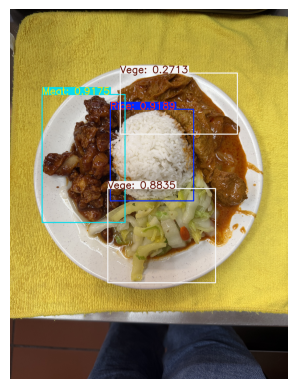

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.frombuffer(bytearray(buffer), dtype=np.uint8)
img = cv2.imdecode(img, cv2.IMREAD_COLOR_RGB)

data = result.json()
names = data['names']

# If preprocessed/resized image is sent to server
xyxy = np.array(data['boxes']['xyxyn'])
xyxy[:, ::2] *= orig_shape[1]
xyxy[:, 1::2] *= orig_shape[0]
xyxy = np.rint(xyxy)

cls = np.array(data['boxes']['cls'], dtype=np.intp).astype(str).tolist()
conf = np.array(data['boxes']['conf']).tolist()

from ultralytics.utils.plotting import Annotator, Colors
colors = Colors()
annotator = Annotator(img)
for bx, cls_idx, score in zip(xyxy, cls, conf):
    annotator.box_label(
        box=bx,
        label=f"{names[cls_idx]}: {score:0.4f}",
        color=colors(cls_idx),
        txt_color=colors(cls_idx)[::-1],
        )

plt.imshow(annotator.im)
plt.axis('off')
plt.show()

#### Request result with image preprocessed to pytorch tensor (Lower internet bandwidth usage)

In [5]:
result = requests.post(url, files={
    "stream": binary_data,
    "meta": json.dumps({"preprocessed": True})
    },headers=headers)

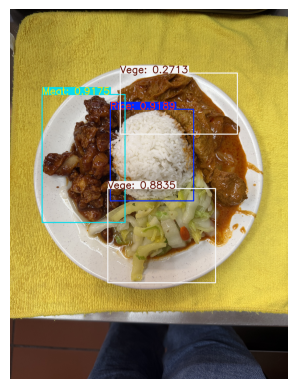

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = np.frombuffer(bytearray(buffer), dtype=np.uint8)
img = cv2.imdecode(img, cv2.IMREAD_COLOR_RGB)

data = result.json()
names = data['names']

# If preprocessed/resized image is sent to server
xyxy = np.array(data['boxes']['xyxyn'])
xyxy[:, ::2] *= orig_shape[1]
xyxy[:, 1::2] *= orig_shape[0]
xyxy = np.rint(xyxy)

cls = np.array(data['boxes']['cls'], dtype=np.intp).astype(str).tolist()
conf = np.array(data['boxes']['conf']).tolist()

from ultralytics.utils.plotting import Annotator, Colors
colors = Colors()
annotator = Annotator(img)
for bx, cls_idx, score in zip(xyxy, cls, conf):
    annotator.box_label(
        box=bx,
        label=f"{names[cls_idx]}: {score:0.4f}",
        color=colors(cls_idx),
        txt_color=colors(cls_idx)[::-1],
        )

plt.imshow(annotator.im)
plt.axis('off')
plt.show()